In [28]:
import numpy as numpy
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms

In [29]:
device  = "cuda" if torch.cuda.is_available() else "cpu"

In [30]:
# 1️⃣ Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [31]:

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:33<00:00, 298kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 101kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 268kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.90MB/s]


In [33]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [35]:

# 2️⃣ CNN Model
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32*12*12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MNISTCNN().to(device)

# 3️⃣ Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4️⃣ Training Loop
epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# 5️⃣ Test accuracy
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100*correct/total:.2f}%")

Epoch 1/3, Loss: 144.5397
Epoch 2/3, Loss: 47.2300
Epoch 3/3, Loss: 32.2470
Test Accuracy: 98.64%


[Tracked] Epoch 1: Loss=0.0256, Train=99.66%, Test=98.89%
[Tracked] Epoch 2: Loss=0.0197, Train=99.73%, Test=98.98%
[Tracked] Epoch 3: Loss=0.0161, Train=99.81%, Test=99.08%


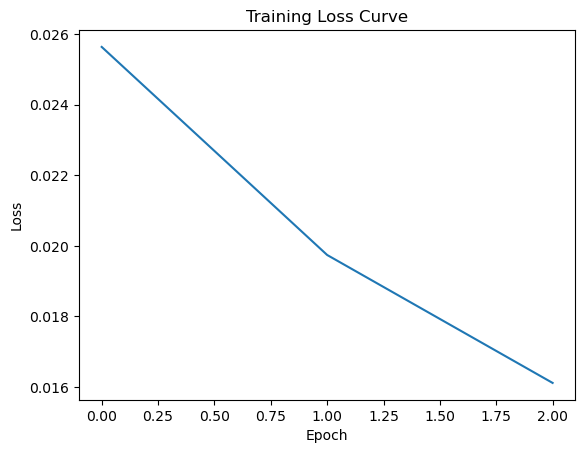

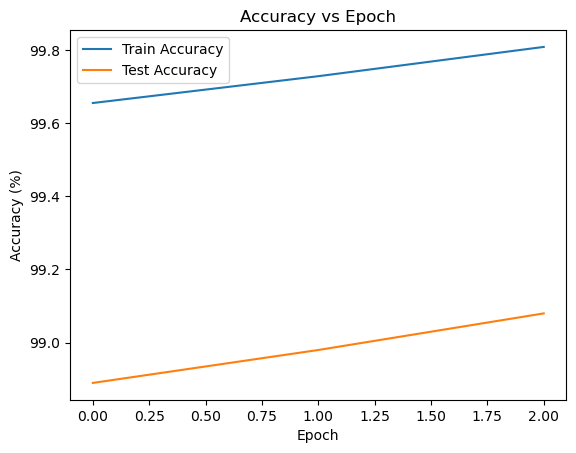

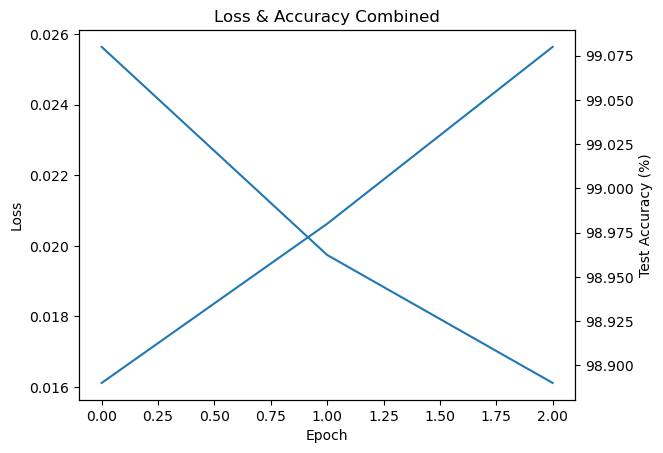

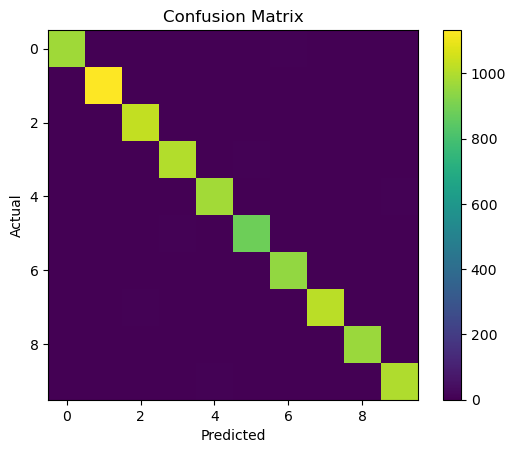

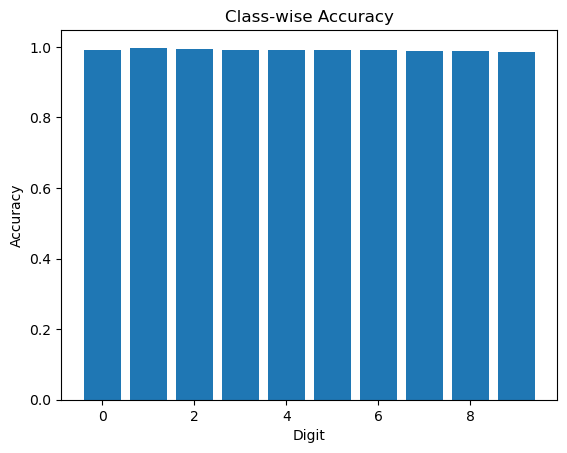

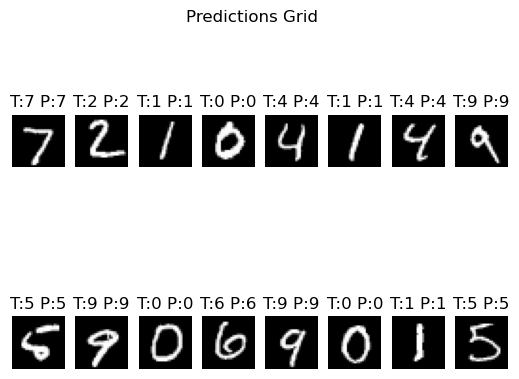

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

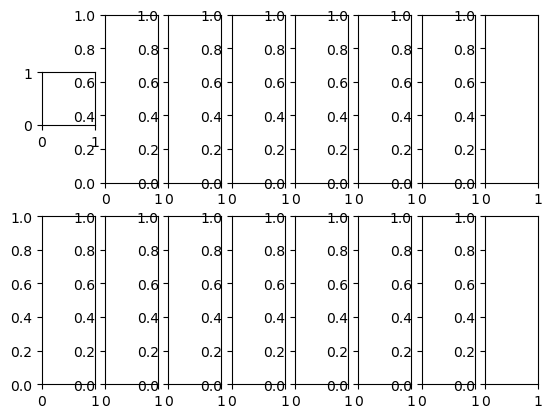

In [ ]:
# ===== FULL VISUALIZATION + METRICS EXTENSION (APPEND BELOW YOUR CODE) =====

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ===== RE-RUN TRAINING WITH METRIC TRACKING =====
loss_history = []
train_acc_history = []
test_acc_history = []

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)

    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    print(f"[Tracked] Epoch {epoch+1}: Loss={avg_loss:.4f}, Train={train_acc:.2f}%, Test={test_acc:.2f}%")

# ===== PLOTS =====

# 📉 Loss Curve
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 📊 Accuracy Curves
plt.figure()
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(test_acc_history, label="Test Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

# 📊 Combined Loss + Accuracy (dual axis)
fig, ax1 = plt.subplots()

ax1.plot(loss_history)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(test_acc_history)
ax2.set_ylabel("Test Accuracy (%)")

plt.title("Loss & Accuracy Combined")
plt.show()

# 📊 Confusion Matrix
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# 📊 Class-wise accuracy bar chart
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(range(10), class_acc)
plt.title("Class-wise Accuracy")
plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.show()

# 🔎 Prediction Grid
fig, axes = plt.subplots(2, 8)

model.eval()
for i in range(16):
    img, label = test_dataset[i]
    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        pred = torch.argmax(output, dim=1).item()

    ax = axes[i//8][i%8]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"T:{label} P:{pred}")
    ax.axis("off")

plt.suptitle("Predictions Grid")
plt.show()

# 🧠 Feature Maps (Conv1)
img, _ = test_dataset[0]
x = img.unsqueeze(0).to(device)

model.eval()
x = torch.relu(model.conv1(x))

fig, axes = plt.subplots(2, 8)
for i in range(16):
    ax = axes[i//8][i%8]
    ax.imshow(x[0, i].detach().cpu().numpy(), cmap="gray")
    ax.axis("off")

plt.suptitle("Conv1 Feature Maps")
plt.show()

# 📊 Histogram of prediction confidence
confidences = []

model.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        max_probs = torch.max(probs, dim=1)[0].cpu().numpy()
        confidences.extend(max_probs)

plt.figure()
plt.hist(confidences, bins=50)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

# 📊 Error visualization (wrong predictions)
fig, axes = plt.subplots(2, 8)
count = 0

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(imgs)):
            if preds[i] != labels[i] and count < 16:
                ax = axes[count//8][count%8]
                ax.imshow(imgs[i].cpu().squeeze(), cmap="gray")
                ax.set_title(f"T:{labels[i]} P:{preds[i].item()}")
                ax.axis("off")
                count += 1
        if count >= 16:
            break

plt.suptitle("Misclassified Samples")
plt.show()